# NASDAQ

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import date, datetime, timedelta
# gráficos interactivos
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
#import chart_studio.plotly as py
# módulos optimización
import scipy.optimize as optimize
import cvxopt as opt
from cvxopt import matrix, spmatrix, sparse
from cvxopt.solvers import qp, options
from cvxopt import blas
# web scrapping
import bs4 as bs
import requests
import lxml
from functools import reduce
# matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from ipysigma import Sigma
from pyvis.network import Network
import requests
from bs4 import BeautifulSoup
from io import StringIO
from dbconnection import MySQLDatabase
sns.set()

In [2]:
db = MySQLDatabase("financialmarkets")

In [3]:
year = '2024'

In [4]:
query = f"""   
    SELECT 
        sp.date,
        c.symbol,
        sp.close_price
    FROM stock_prices_dax sp
    JOIN companies c ON sp.company_id = c.company_id
    WHERE YEAR(sp.date) = {year};
"""
df = db.execute_query(query)
print(f"Shape: {df.shape}")

✅ Conexión exitosa
Shape: (15006, 3)


In [5]:
base = df.pivot_table(index='date', columns=['symbol'], values='close_price').reset_index()
base.head()

symbol,date,1COV.DE,ADS.DE,AIR.PA,ALV.DE,BAS.DE,BAYN.DE,BEI.DE,BMW.DE,BNR.DE,...,RHM.DE,RWE.DE,SAP.DE,SHL.DE,SIE.DE,SRT3.DE,SY1.DE,VNA.DE,VOW3.DE,ZAL.DE
0,2024-01-01,52.44,182.705,140.905,244.2,48.9975,34.1513,135.175,101.53,83.04,...,296.15,41.12,137.875,52.525,168.39,342.275,98.575,28.1725,112.61,21.0825
1,2024-01-02,52.36,182.22,141.28,244.95,49.07,34.325,135.0,101.78,82.98,...,299.2,41.1,137.34,52.5,167.88,345.3,98.22,28.05,112.88,20.96
2,2024-01-03,52.18,179.16,137.16,242.55,47.76,34.405,135.3,99.51,82.0,...,297.0,40.42,137.12,51.36,162.32,331.2,98.02,27.45,110.86,20.21
3,2024-01-04,52.78,173.76,139.38,245.5,47.695,35.235,135.05,101.0,82.4,...,305.1,40.78,136.44,51.78,162.42,320.8,97.56,27.43,112.32,19.375
4,2024-01-05,52.58,173.48,139.7,243.9,46.8,35.22,134.0,100.66,81.66,...,305.1,40.74,137.08,51.58,160.5,316.1,97.2,27.1,113.26,19.06


In [6]:
base = base.dropna(axis=1).set_index('date')

In [7]:
# Calculo de retornos diarios
returns = base.pct_change().dropna()

# Matriz de correlación
correlation_matrix = returns.corr()

C:\Users\HP\AppData\Local\Temp\ipykernel_6996\3676616670.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  returns = base.pct_change().dropna()


In [13]:
# Crear heatmap
# plt.figure(figsize=(8,6))
# sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Heatmap de la matriz de correlaciones")
# plt.show()

**Gráfico Riesgo Rendimiento**

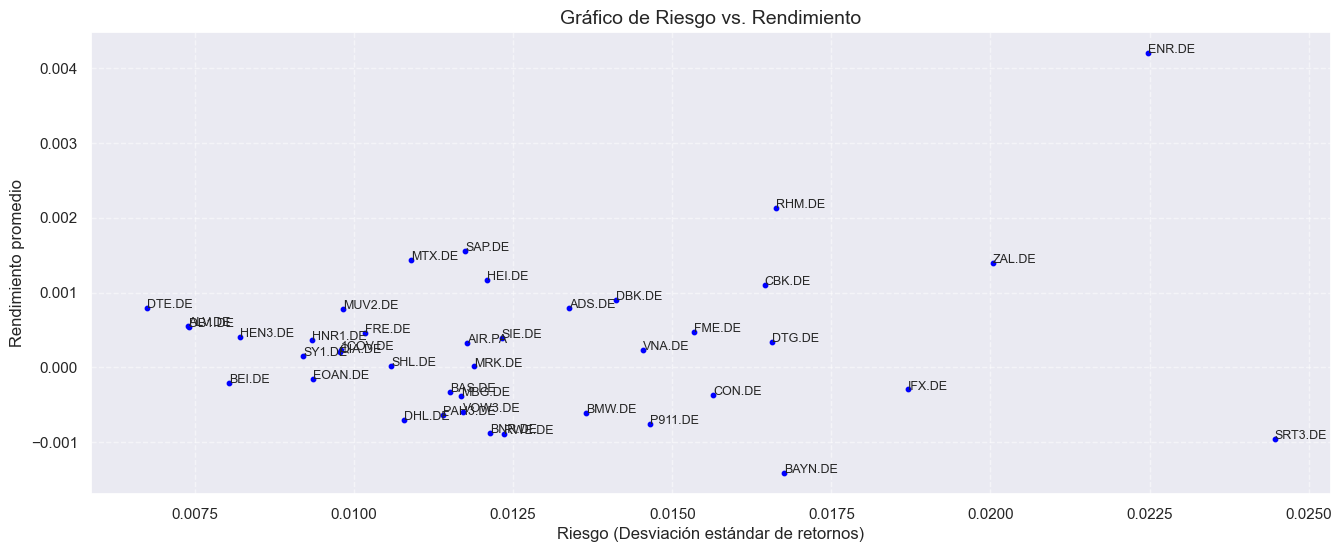

In [9]:
#Calcular rendimiento promedio (mean return) y riesgo (desviación estándar)
#returns = returns.drop(columns=["CHRD", "ATON", "PROP", "SOBR"])
mean_returns = returns.mean(axis=0)
risk = returns.std(axis=0)

# Crear figura
plt.figure(figsize=(16,6))
plt.scatter(risk, mean_returns, color='blue', s=10)

# Etiquetas de los activos
for i in mean_returns.index:
    plt.text(risk[i] , mean_returns[i], i, fontsize=9)

# Títulos y etiquetas
plt.title("Gráfico de Riesgo vs. Rendimiento", fontsize=14)
plt.xlabel("Riesgo (Desviación estándar de retornos)", fontsize=12)
plt.ylabel("Rendimiento promedio", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [11]:
# Set correlation threshold
threshold = 0.60

# Create graph
G = nx.Graph()

# Add nodes
for ticker in correlation_matrix.columns:
    G.add_node(ticker)

# Add edges with correlation above threshold
for i, stock1 in enumerate(correlation_matrix.columns):
    for j, stock2 in enumerate(correlation_matrix.columns):
        if i < j:
            corr = correlation_matrix.iloc[i, j]
            if abs(corr) >= threshold:
                G.add_edge(stock1, stock2, weight=corr)


Sigma.write_html(
    G,
    f"./grafos/dax_{year}.html",
    fullscreen=True,
    node_metrics=['louvain'],
    node_color='louvain',
    node_size_range=(3, 15),
    max_categorical_colors=30,
    default_edge_type='curve',
    node_border_color_from='node',
    default_node_label_size=14,
    node_size=G.degree
)

In [16]:
db.close()

🔒 Conexión cerrada
